<a href="https://colab.research.google.com/github/AHMerrill/Unstructured-Data-1/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unstructured Data Assignment 1 - Group 10

**Group members**: Ethan Davenport, Nikhil Kumar, Maru Lasala, Grace Lin, Kristen Lowe, Zan Merrill (Alphabetically ordered by last name)

## Part 0 Installs and Imports

* Install Selenium (if necessary)



In [2]:
# run this if necessary
!pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0


* Import necessary libraries

In [23]:
# imports

from selenium import webdriver # selenium webdriver api
from selenium.webdriver.chrome.service import Service # control chromedriver process
from selenium.webdriver.common.by import By # locator strategies (css, xpath, etc.)
from selenium.webdriver.chrome.options import Options # configure chrome options
from selenium.webdriver.support.ui import WebDriverWait # explicit waits for elements
from selenium.webdriver.support import expected_conditions as EC # predicates for waits
import pandas as pd # tabular data and dataframe creation
import time # sleep between page loads
import re # regular expressions for text cleanup
from tqdm import tqdm # neat progress bar
from google.colab import files
# optional: if you still see weird output, force tqdm to stdout only
# import sys

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.manifold import MDS
from IPython.display import display
import seaborn as sns

## Part 1 Data Collection (Web Scraping)

* Web scrape from Edmunds

In [5]:
# made with GPT5

# some initial parameters
TARGET_COUNT = 10_000 # desired total number of comments to scrape
BASE_URL = "https://forums.edmunds.com/discussion/2864/general/x/entry-level-luxury-performance-sedans"  # online thread base

# setup the browser
chrome_options = Options() # create a chrome options object
chrome_options.add_argument('--headless=new') # run chrome in headless mode
chrome_options.add_argument('--no-sandbox') # disable sandbox
chrome_options.add_argument('--disable-dev-shm-usage') # avoid shared memory issues on linux
chrome_options.add_argument('--disable-gpu') # disable gpu acceleration
chrome_options.add_argument('--window-size=1920,1080') # ensure large viewport

# service = Service('/usr/local/bin/chromedriver') # adjust this if necessary
driver = webdriver.Chrome(options=chrome_options) # start webdriver instance
wait = WebDriverWait(driver, 20) # explicit wait helper with 20s timeout

# url helper for pagination
def page_url(page_num:int) -> str: # function to build the correct url
    """page 1 is the base url; page 2+ use /p{n}."""
    if page_num <= 1:
        return BASE_URL
    return f"{BASE_URL}/p{page_num}"

# wait until posts render
def wait_for_posts():
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, ".MessageList"))) # wait until post container appears
    time.sleep(0.5) # small buffer for rendering

# javascript to remove blockquotes
REMOVE_QUOTES_JS = r"""
const message = arguments[0].cloneNode(true);
message.querySelectorAll(
  'blockquote, .UserQuote, .QuoteText, .QuoteAuthor, .QuoteFoldingWrapper'
).forEach(el => el.remove());
return message.innerText;
"""

# helper to normalize whitespace
def clean_text(s:str | None) -> str | None:
    if not s:
        return None
    s = re.sub(r'\r\n|\r', '\n', s) # normalize line endings
    s = re.sub(r'[ \t\f\v]+', ' ', s) # collapse extra spaces/tabs
    s = re.sub(r'\n{3,}', '\n\n', s) # limit blank lines
    return s.strip() # trim whitespace

# scrape all posts on the current page
def scrape_current_page() -> list[dict]:
    rows = [] # store results
    posts = driver.find_elements(By.CSS_SELECTOR, ".MessageList .Item") # find post containers
    for post in posts:
        try:
            # author
            try:
                author = post.find_element(By.CSS_SELECTOR, "a.Username").text.strip()
            except:
                author = None

            # date
            try:
                date_el = post.find_element(By.XPATH, ".//time | .//abbr")
                dtg = (date_el.get_attribute("datetime")
                       or date_el.get_attribute("title")
                       or date_el.text.strip())
            except:
                dtg = None

            # comment (remove blockquotes)
            try:
                msg_el = post.find_element(By.CSS_SELECTOR, "div.Message")
                raw_text = driver.execute_script(REMOVE_QUOTES_JS, msg_el)
                comment = clean_text(raw_text)
            except:
                comment = None

            rows.append({"author": author, "date": dtg, "comment": comment})
        except:
            pass # skip bad posts
    return rows

# crawl loop until target count reached
all_rows = []
page = 1

# single, tidy progress bar (no stacked lines)
progress = tqdm(
    total=TARGET_COUNT,
    desc="comments scraped",
    unit="comment",
    dynamic_ncols=True,
    mininterval=0.3,
    smoothing=0.1,
    # file=sys.stdout,  # uncomment if your env sends tqdm to stderr weirdly
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] {postfix}"
)

try:
    while len(all_rows) < TARGET_COUNT:
        url = page_url(page) # build url
        driver.get(url) # open page

        try:
            wait_for_posts() # wait until posts render
        except Exception as e:
            # use tqdm.write so it doesn't break the bar
            tqdm.write(f"no posts container on page {page} ({url}). stopping. error: {e}")
            break

        rows = scrape_current_page() # scrape rows
        if not rows:
            tqdm.write("no posts on this page — likely end of thread.")
            break

        all_rows.extend(rows) # add results
        progress.update(len(rows)) # update bar by number of comments
        progress.set_postfix_str(f"pages={page}") # show current page without new lines

        if len(all_rows) >= TARGET_COUNT:
            break

        page += 1
        time.sleep(1.0) # polite pause
finally:
    driver.quit() # close browser
    progress.close() # close progress bar

# build dataframe
car_comments_df = pd.DataFrame(all_rows[:TARGET_COUNT]) # clip to target count
print(f"\ntotal collected: {len(car_comments_df)}")

car_comments_df


comments scraped: |          | 10001/? [22:00<00:00,  7.57comment/s] , pages=200



total collected: 10000


,author,date,comment
0,cybersol,2002-03-23T19:04:32+00:00,Entry level performance luxury sedans are a ho...
1,merc1,2002-03-25T05:54:02+00:00,I personally think that with a few tweaks the ...
2,fredvh,2002-03-25T07:06:29+00:00,I am debating a new purchase and these two are...
3,blueguydotcom,2002-03-25T17:02:27+00:00,"Great handling, RWD, excellent engine and the ..."
4,hungrywhale,2002-03-25T23:04:37+00:00,And no manual tranny. That may not matter to y...
...,...,...,...
9995,sevenfeet0,2007-09-26T17:29:17+00:00,"Well, part of the reason the back seat room is..."
9996,blueguydotcom,2007-09-26T17:43:26+00:00,"Wow, interesting. Can't argue with that. Why n..."
9997,circlew,2007-09-26T17:51:27+00:00,"Well, no ELLPS can be comfortable for you! Go ..."
9998,150mphclub,2007-09-26T17:55:02+00:00,I am with you sevenfeet. I sometimes drive 700...


* Clean up scraped comments

In [8]:
# clean comments in place
car_comments_df['comment'] = car_comments_df['comment'].str.replace(r'[^A-Za-z0-9\s]','', regex = True) # keep only letters, numbers, spaces
car_comments_df['comment'] = car_comments_df['comment'].str.replace(r'\s+',' ', regex = True).str.strip() # collapse multiple spaces
car_comments_df['comment'] = car_comments_df['comment'].str.lower() # lowercase everything

# convert date to datetime
car_comments_df['date'] = pd.to_datetime(
    car_comments_df['date'],
    errors = 'coerce', # invalid or missing go to NaT
    utc = True # standardize to UTC
)

car_comments_df


,author,date,comment
0,cybersol,2002-03-23 19:04:32+00:00,entry level performance luxury sedans are a ho...
1,merc1,2002-03-25 05:54:02+00:00,i personally think that with a few tweaks the ...
2,fredvh,2002-03-25 07:06:29+00:00,i am debating a new purchase and these two are...
3,blueguydotcom,2002-03-25 17:02:27+00:00,great handling rwd excellent engine and the be...
4,hungrywhale,2002-03-25 23:04:37+00:00,and no manual tranny that may not matter to yo...
...,...,...,...
9995,sevenfeet0,2007-09-26 17:29:17+00:00,well part of the reason the back seat room isn...
9996,blueguydotcom,2007-09-26 17:43:26+00:00,wow interesting cant argue with that why not g...
9997,circlew,2007-09-26 17:51:27+00:00,well no ellps can be comfortable for you go wi...
9998,150mphclub,2007-09-26 17:55:02+00:00,i am with you sevenfeet i sometimes drive 700 ...


* Save comments to CSV on local device (if needed)

In [9]:
# Save full dataset to CSV
car_comments_df.to_csv("../data/car_comments.csv", index=False, encoding="utf-8")

# If wanted, trigger a download of the CSV to your computer
files.download("../data/car_comments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Part 2 Language Patterns

### Task A: Zipf's Law

In [10]:
# --- clean the text column: drop NaNs/empties, ensure strings ---
texts = (
    car_comments_df['comment']
      .dropna()            # remove NaNs
      .astype(str)         # force to string (after dropna to avoid 'nan' strings)
      .str.strip()
)
texts = texts[texts != ""]  # drop empty strings

vectorizer = CountVectorizer(lowercase = True, stop_words = None)
X = vectorizer.fit_transform(texts)

word_counts = np.asarray(X.sum(axis = 0)).ravel()
vocab = np.array(vectorizer.get_feature_names_out())

zipf_df = pd.DataFrame({'word':vocab,'count':word_counts})
zipf_df = zipf_df.sort_values('count', ascending = False).reset_index(drop = True)
zipf_df['rank'] = np.arange(1,len(zipf_df)+1)

zipf_df['log_rank'] = np.log(zipf_df['rank'])
zipf_df['log_count'] = np.log(zipf_df['count'])

zipf_df

,word,count,rank,log_rank,log_count
0,the,52349,1,0.000000,10.865688
1,and,20788,2,0.693147,9.942131
2,to,20122,3,1.098612,9.909569
3,is,15571,4,1.386294,9.653165
4,of,14327,5,1.609438,9.569901
...,...,...,...,...,...
41830,zerofun,1,41831,10.641393,0.000000
41831,zerodont,1,41832,10.641417,0.000000
41832,zing,1,41833,10.641441,0.000000
41833,zhpi,1,41834,10.641465,0.000000


In [11]:
X = sm.add_constant(zipf_df['log_rank']) # predictor = log(rank)
y = zipf_df['log_count'] # response = log(count)

model = sm.OLS(y, X).fit(cov_type = 'HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_count   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                 5.079e+05
Date:                Wed, 10 Sep 2025   Prob (F-statistic):               0.00
Time:                        16:50:12   Log-Likelihood:                -9029.0
No. Observations:               41835   AIC:                         1.806e+04
Df Residuals:                   41833   BIC:                         1.808e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.7136      0.017    756.316      0.0

The confidence interval for the log_rank coefficient does **NOT** include -1.  This means that there is not an exact -1 relationship between log_rank and log_count.  Zipf's law doesn't hold _exactly_, but there is still strong evidence of a power-law fit

In [12]:
slope_hat = model.params['log_rank']
se = model.bse['log_rank']
t_stat = (slope_hat + 1) / se # because null hypothesis: slope = -1
dfree = model.df_resid
from scipy.stats import t as tdist
pval = 2* (1-tdist.cdf(abs(t_stat), dfree))

print(f"\nSlope estimate: {slope_hat:.4f}")
print(f"Std error: {se:.4f}")
print(f"T-stat vs -1: {t_stat:.2f}, p-value = {pval:.4g}")


Slope estimate: -1.2424
Std error: 0.0017
T-stat vs -1: -139.05, p-value = 0


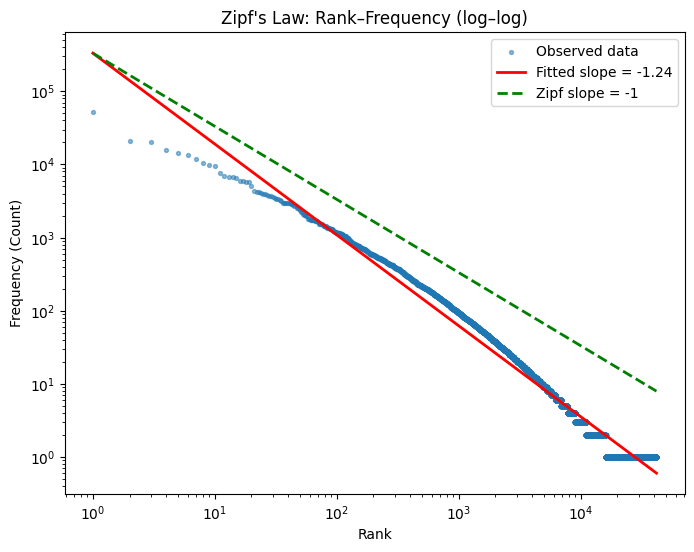

In [13]:
# Regression parameters
a = model.params["const"]
b = model.params["log_rank"]

# Range of ranks to plot
rline = np.linspace(zipf_df["rank"].min(), zipf_df["rank"].max(), 500)

# Fitted regression line
fitted = np.exp(a + b * np.log(rline))

# Reference Zipf line with slope = -1
zipf_ref = np.exp(a - 1 * np.log(rline))

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(zipf_df["rank"], zipf_df["count"], s=8, alpha=0.5, label="Observed data")
plt.plot(rline, fitted, color="red", lw=2, label=f"Fitted slope = {b:.2f}")
plt.plot(rline, zipf_ref, color="green", linestyle="--", lw=2, label="Zipf slope = -1")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Rank")
plt.ylabel("Frequency (Count)")
plt.title("Zipf's Law: Rank–Frequency (log–log)")
plt.legend()
plt.show()

* Top 100 most common words

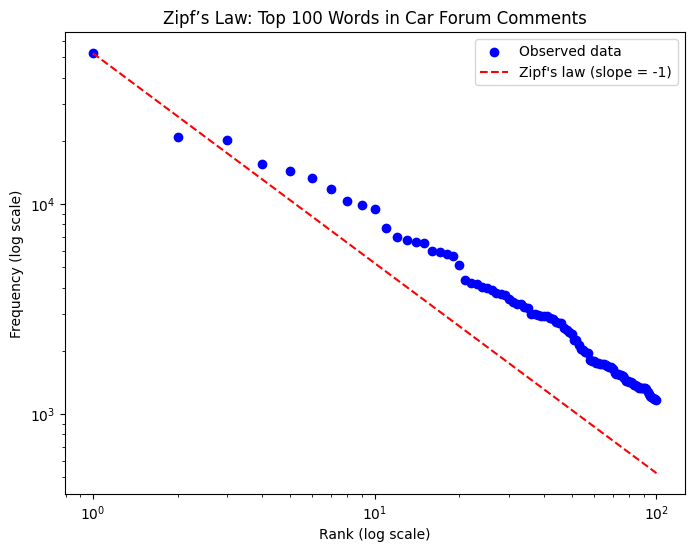

In [14]:
# --- select the top 100 most common words ---
top_n = 100
top_df = zipf_df.head(top_n)

# --- theoretical Zipf prediction ---
# frequency ~ C / rank
# Normalize constant C so that rank=1 prediction equals observed max frequency
C = top_df['count'].iloc[0]
theoretical = C / top_df['rank']

# --- plotting ---
plt.figure(figsize=(8,6))

# observed word frequencies (scatter)
plt.scatter(top_df['rank'], top_df['count'],
            color='blue', label='Observed data')

# Zipf theoretical curve (1/rank)
plt.plot(top_df['rank'], theoretical,
         color='red', linestyle='--', label="Zipf's law (slope = -1)")

# log-log scale to show power-law relationship
plt.xscale('log')
plt.yscale('log')

# labels and title
plt.xlabel('Rank (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Zipf’s Law: Top 100 Words in Car Forum Comments')
plt.legend()

In [16]:
brand_aliases = {

    "acura": [
        "acura", "ilx", "integra", "legend", "mdx", "rdx", "rlx", "rsx", "tsx", "vigor"
    ],

    "alfa romeo": [
        "147", "156", "159", "4 c", "4c", "8 c", "8c", "alfa romeo", "alfa romeos", "giulia", "giulietta", "stelvio",
        "tonale"
    ],

    "aston martin": [
        "aston martin", "aston martins", "db 11", "db 12", "db 7", "db 9", "db11", "db12", "db7", "db9", "dbs", "dbx",
        "dbx 707", "dbx707", "rapide", "valhalla", "valkyrie", "vanquish", "vantage"
    ],

    "audi": [
        "a 3", "a 4", "a 5", "a 6", "a 7", "a 8", "a3", "a4", "a5", "a6", "a7", "a8",
        "audi", "audis", "e tron", "e-tron", "etron", "q 3", "q 4 e tron", "q 4 e-tron", "q 4 etron", "q 5", "q 7", "q 8",
        "q 8 e tron", "q 8 e-tron", "q 8 etron", "q3", "q4 e tron", "q4 e-tron", "q4 etron", "q4-e-tron", "q4-etron", "q4e tron", "q4e-tron", "q4etron",
        "q5", "q7", "q8", "q8 e tron", "q8 e-tron", "q8 etron", "q8-e-tron", "q8e tron", "q8e-tron", "q8etron", "quattro", "r 8",
        "r8", "rs 5", "rs 6", "rs 7", "rs5", "rs6", "rs7", "sq 5", "sq5", "tt"
    ],

    "bentley": [
        "azure", "bentayga", "bentley", "bentleys", "brooklands", "continental gt", "continental-gt", "continentalgt", "flying spur", "flying-spur", "flyingspur", "mulsanne"
    ],

    "bmw": [
        "1 series", "1-series", "128 i", "128i", "1er", "1series", "2 series", "2-series", "2er", "2series", "3 er", "3 series",
        "3-series", "328 i", "328i", "330 c", "330 ci", "330c", "330ci", "335 d", "335 i", "335d", "335i", "3er",
        "3series", "4 series", "4-series", "4er", "4series", "5 er", "5 series", "5-series", "528 i", "528i", "535 i", "535i",
        "5er", "5series", "6 series", "6-series", "640 i", "640i", "6er", "6series", "7 series", "7-series", "7er", "7series",
        "8 series", "8-series", "8er", "8series", "beamer", "bimmer", "bmw", "bmwesque", "bmws", "gran coupe", "gran-coupe",
        "grancoupe", "i 3", "i 4", "i 5", "i 7", "i 8", "i3", "i4", "i5", "i7", "i8",
        "ix 3", "ix 5", "ix 7", "ix3", "ix5", "ix7", "m 2", "m 3", "m 4", "m 5", "m 6", "m 8",
        "m2", "m3", "m4", "m5", "m6", "m8", "x 1", "x 2", "x 3", "x 4", "x 5",
        "x 6", "x 7", "x1", "x2", "x3", "x4", "x5", "x6", "x7", "xdrive", "z 3", "z 4",
        "z 8", "z3", "z4", "z8"
    ],

    "bugatti": [
        "bolide", "bugatti", "bugattis", "bughatti", "centodieci", "chiron", "divo", "eb 110", "eb110", "veyron"
    ],

    "buick": [
        "buick", "buicks", "century", "enclave", "encore", "la crosse", "la-crosse", "lacrosse", "park avenue", "park-avenue", "parkavenue", "regal"
    ],

    "cadillac": [
        "ats", "brougham", "caddi", "caddy", "cadillac", "cadillacs", "catera", "celestiq", "ct 4", "ct 4 v", "ct 4-v", "ct 4v",
        "ct 5", "ct 5 v", "ct 5-v", "ct 5v", "ct 6", "ct 6 v", "ct 6-v", "ct 6v", "ct4", "ct4 v", "ct4-v", "ct4v",
        "ct5", "ct5 v", "ct5-v", "ct5v", "ct6", "ct6 v", "ct6-v", "ct6v", "cts", "cts v", "cts-v", "ctsv",
        "deville", "dts", "eldorado", "elr", "escalade", "escalade esv", "escalade-esv", "escaladeesv", "lyriq", "seville", "srx", "sts",
        "xt 4", "xt 5", "xt 6", "xt4", "xt5", "xt6", "xts"
    ],

    "chevrolet": [
        "agile", "aveo", "blazer", "bolt", "bolt euv", "bolt ev", "bolt-euv", "bolt-ev", "bolteuv", "boltev", "camaro", "caprice",
        "captiva", "cavalier", "celta", "chevrolet", "chevrolets", "chevvy", "chevy", "cobalt", "colorado", "corvette", "cruze", "equinox",
        "express", "grand blazer", "grand-blazer", "grandblazer", "impala", "lacetti", "lanos", "lova", "lumina", "malibu", "malibus", "montana",
        "n 200", "n200", "niva", "omega", "onix", "optra", "orlando", "prisma", "s  10", "s 10", "s- 10", "s-10",
        "s10", "sail", "silverado", "sonic", "spark", "suburban", "tahoe", "tavera", "tornado", "tracker", "trailblazer", "traverse",
        "trax", "uplander", "volt"
    ],

    "chrysler": [
        "300 m", "300m", "chrysler", "chrysler  200", "chrysler  300", "chrysler 200", "chrysler 300", "chrysler-200", "chrysler-300", "chrysler200", "chrysler300", "chryslers",
        "cruiser", "lx", "pacifica", "sebring", "town and country", "town-and-country", "townandcountry"
    ],

    "dodge": [
        "avenger", "caliber", "challenger", "charger", "dart", "dodge", "dodges", "durango", "intrepid", "journey", "magnum", "neon",
        "ram", "stealth", "viper"
    ],

    "ferrari": [
        "296", "360", "430", "458", "488", "550", "575", "599", "612", "812", "california", "challenge stradale",
        "challenge-stradale", "challengestradale", "enzo", "f 355", "f 430", "f 8", "f 8 tributo", "f355", "f430", "f8", "f8 tributo", "f8-tributo",
        "f8tributo", "ferrari", "ferraris", "gto", "laferrari", "portofino", "roma", "sf 90", "sf 90 stradale", "sf90", "sf90 stradale", "sf90-stradale",
        "sf90stradale"
    ],

    "ford": [
        "bronco", "bronco sport", "bronco-sport", "broncosport", "c max", "c-max", "cmax", "crownvictoria", "ecoline", "ecosport", "edge", "escape",
        "everest", "expedition", "explorer", "f  150", "f  150 lightning", "f  250", "f  350", "f  450", "f 150", "f 150 lightning", "f 150lightning", "f 250",
        "f 350", "f 450", "f- 150", "f- 150 lightning", "f- 250", "f- 350", "f- 450", "f-150", "f-150 lightning", "f-150-lightning", "f-150lightning", "f-250",
        "f-350", "f-450", "f150", "f150 lightning", "f150-lightning", "f150lightning", "f250", "f350", "f450", "fiesta", "five hundred", "five-hundred",
        "fivehundred", "flex", "focus", "ford", "fords", "freestar", "fusion", "fusionmilan", "fusions", "galaxy", "kuga",
        "lightning", "mach e", "mach-e", "mache", "maverick", "mustang", "mustang mach e", "mustang mach-e", "mustang mache", "mustang-mach-e", "mustangmach e", "mustangmach-e",
        "mustangmache", "ranger", "s max", "s-max", "smax", "supervan", "taurus", "tourneo", "transit", "transit connect", "transit-connect", "transitconnect"
    ],

    "genesis": [
        "g 70", "g 80", "g 90", "g70", "g80", "g90", "genesis", "gv 60", "gv 70", "gv 80", "gv60", "gv70",
        "gv80"
    ],

    "gmc": [
        "acadia", "canyon", "gmc", "gmcs", "hummer ev", "hummer-ev", "hummerev", "jimmy", "sierra", "yukon", "yukon xl",
        "yukon-xl", "yukonxl"
    ],

    "honda": [
        "5 dr", "5dr", "accord", "accords", "acty", "aria", "brio", "civic", "cr v", "cr z",
        "cr-v", "cr-z", "crider", "crosstour", "crv", "crz", "ex l", "ex-l", "exl", "fcx", "freed", "hobio",
        "honda", "hondas", "insight", "inspire", "jade", "jazz", "legend", "mobilio", "n box", "n one", "n wgn", "n-box",
        "n-one", "n-wgn", "nbox", "none", "nsx", "nwgn", "odessey", "odyssey", "pilot", "prelude", "ridgeline", "shuttle",
        "spike", "spirior", "stepwgn", "stream", "vamos", "vezel", "zest"
    ],

    "hyundai": [
        "accent", "atos", "atoz", "avante", "azera", "centennial", "click", "dynasty", "elantra", "equus", "excel", "genesis",
        "getz", "grandeur", "hyundai", "hyundais", "i 10", "i 20", "i 30", "i 40", "i 45", "i10", "i20", "i30",
        "i40", "i45", "ioniq", "ioniq  5", "ioniq  6", "ioniq 5", "ioniq 6", "ioniq-5", "ioniq-6", "ioniq5", "ioniq6", "ix 20",
        "ix20", "kona", "lantra", "lavity", "matrix", "palisade", "pony", "santa", "santa fe", "santa-fe", "santafe", "santamo",
        "santro", "scoupe", "sonata", "sonatas", "stellar", "tiburon", "tucson", "tuscani", "veloster", "venue", "veracruz", "verna",
        "xcent", "xg"
    ],

    "infiniti": [
        "6 mt", "6mt", "fx 35", "fx35", "g 25", "g 37", "g25", "g37", "infiniti", "q 50", "q 60", "q 70",
        "q50", "q60", "q70", "qx 50", "qx 60", "qx 70", "qx50", "qx60", "qx70"
    ],

    "jaguar": [
        "e pace", "e-pace", "epace", "f pace", "f type", "f-pace", "f-type", "fpace", "ftype", "i pace", "i-pace", "ipace",
        "jaguar", "jaguars", "xe", "xf", "xj", "xk"
    ],

    "jeep": [
        "cherokee", "cj", "commander", "compass", "gladiator", "grand cherokee", "grand wagoneer", "grand-cherokee", "grand-wagoneer", "grandcherokee", "grandwagoneer", "jeep",
        "jeeps", "liberty", "patriot", "renegade", "wagoneer", "wrangler"
    ],

    "kia": [
        "cadenza", "ev 6", "ev 9", "ev6", "ev9", "forte", "k 5", "k 900", "k5", "k900", "kia", "kias",
        "koup", "niro", "optima", "rio", "sedona", "seltos", "sorento", "soul", "sportage", "stinger", "telluride"
    ],

    "koenigsegg": [
        "agera", "cc 8s", "cc8 s", "cc8s", "ccx", "gemera", "jesko", "koenigsegg", "koenigseggs", "one: 1", "one:1", "regera"
    ],

    "lamborghini": [
        "aventador", "diablo", "gallardo", "huracan", "huracán", "lamborghini", "lamborghinis", "lp 640", "lp640", "murcielago", "murciélago", "performante",
        "revuelto", "sto", "sv", "svj", "urus"
    ],

    "land rover": [
        "defender", "discovery", "discovery sport", "discovery-sport", "discoverysport", "land rover", "land rovers", "lr 2", "lr 3", "lr 4", "lr2", "lr3",
        "lr4", "range rover", "range rover evoque", "range rover sport", "range rover velar", "range-rover", "range-rover-evoque", "range-rover-sport", "range-rover-velar", "rangerover", "rangeroverevoque", "rangeroversport",
        "rangerovervelar"
    ],

    "lexus": [
        "ct", "es", "es  300h", "es  330", "es  350", "es 300 h", "es 300h", "es 330", "es 350", "es- 300h", "es- 330", "es- 350",
        "es-300 h", "es-300h", "es-330", "es-350", "es300 h", "es300h", "es330", "es350", "gs", "gs  300", "gs  350", "gs  450h",
        "gs 300", "gs 350", "gs 450 h", "gs 450h", "gs f", "gs- 300", "gs- 350", "gs- 450h", "gs-300", "gs-350", "gs-450 h", "gs-450h",
        "gs-f", "gs300", "gs350", "gs450 h", "gs450h", "gsf", "gx", "gx  460", "gx  550", "gx 460", "gx 550", "gx- 460",
        "gx- 550", "gx-460", "gx-550", "gx460", "gx550", "hs", "is  200", "is  250", "is  300", "is  350", "is  500",
        "is 200", "is 250", "is 300", "is 350", "is 500", "is- 200", "is- 250", "is- 300", "is- 350", "is- 500", "is-200", "is-250",
        "is-300", "is-350", "is-500", "is200", "is250", "is300", "is350", "is500", "lbx", "lc", "lc  500", "lc  500h",
        "lc 500", "lc 500 h", "lc 500h", "lc- 500", "lc- 500h", "lc-500", "lc-500 h", "lc-500h", "lc500", "lc500 h", "lc500h", "lexus",
        "lexuses", "lfa", "ls", "ls  400", "ls  430", "ls  460", "ls  500", "ls  500h", "ls 400", "ls 430", "ls 460", "ls 500",
        "ls 500 h", "ls 500h", "ls- 400", "ls- 430", "ls- 460", "ls- 500", "ls- 500h", "ls-400", "ls-430", "ls-460", "ls-500", "ls-500 h",
        "ls-500h", "ls400", "ls430", "ls460", "ls500", "ls500 h", "ls500h", "lx", "lx  470", "lx  570", "lx  600", "lx 470",
        "lx 570", "lx 600", "lx- 470", "lx- 570", "lx- 600", "lx-470", "lx-570", "lx-600", "lx470", "lx570", "lx600", "nx",
        "nx  200t", "nx  300", "nx  300h", "nx  350", "nx  350h", "nx 200 t", "nx 200t", "nx 300", "nx 300 h", "nx 300h", "nx 350", "nx 350 h",
        "nx 350h", "nx- 200t", "nx- 300", "nx- 300h", "nx- 350", "nx- 350h", "nx-200 t", "nx-200t", "nx-300", "nx-300 h", "nx-300h", "nx-350",
        "nx-350 h", "nx-350h", "nx200 t", "nx200t", "nx300", "nx300 h", "nx300h", "nx350", "nx350 h", "nx350h", "rc", "rc  300",
        "rc  350", "rc 300", "rc 350", "rc f", "rc- 300", "rc- 350", "rc-300", "rc-350", "rc-f", "rc300", "rc350", "rcf",
        "rx", "rx  300", "rx  330", "rx  350", "rx  350h", "rx  400h", "rx  450h", "rx  450h+", "rx  500h", "rx  500h+", "rx 300", "rx 330",
        "rx 350", "rx 350 h", "rx 350h", "rx 400 h", "rx 400h", "rx 450 h", "rx 450 h+", "rx 450h", "rx 450h+", "rx 500 h", "rx 500 h+", "rx 500h",
        "rx 500h+", "rx- 300", "rx- 330", "rx- 350", "rx- 350h", "rx- 400h", "rx- 450h", "rx- 450h+", "rx- 500h", "rx- 500h+", "rx-300", "rx-330",
        "rx-350", "rx-350 h", "rx-350h", "rx-400 h", "rx-400h", "rx-450 h", "rx-450 h+", "rx-450h", "rx-450h+", "rx-500 h", "rx-500 h+", "rx-500h",
        "rx-500h+", "rx300", "rx330", "rx350", "rx350 h", "rx350h", "rx400 h", "rx400h", "rx450 h", "rx450 h+", "rx450h", "rx450h+",
        "rx500 h", "rx500 h+", "rx500h", "rx500h+", "rz", "tx", "ux"
    ],

    "lincoln": [
        "lincoln", "mkc", "mks", "mkt", "mkx", "mkz", "navigator", "town car", "town-car", "towncar", "zephyr"
    ],

    "lotus": [
        "eletre", "elise", "emira", "evija", "evora", "exige", "lotus"
    ],

    "lucid": [
        "lucid", "lucids"
    ],

    "maserati": [
        "ghibli", "grancabrio", "granturismo", "levante", "maserati", "maseratis", "mc 20", "mc20", "quattroporte"
    ],

    "mazda": [
        "6 i", "6i", "atenza", "axela", "az offroad", "az wagon", "az-offroad", "az-wagon", "azoffroad", "azwagon", "biante", "bongo",
        "bt  50", "bt 50", "bt- 50", "bt-50", "bt50", "carol", "cx  30", "cx  5", "cx  50", "cx  7", "cx  9", "cx  90",
        "cx 30", "cx 5", "cx 50", "cx 7", "cx 9", "cx 90", "cx- 30", "cx- 5", "cx- 50", "cx- 7", "cx- 9", "cx- 90",
        "cx-30", "cx-5", "cx-50", "cx-7", "cx-9", "cx-90", "cx30", "cx5", "cx50", "cx7", "cx9", "cx90",
        "demio", "familia", "mazda", "mazda 2", "mazda 3", "mazda 5", "mazda 6", "mazda 6i", "mazda 6s", "mazda 8", "mazda2", "mazda3",
        "mazda5", "mazda6", "mazda6 i", "mazda6 s", "mazda6i", "mazda6s", "mazda8", "mazdas", "millenia", "mpv", "mx  30", "mx  5",
        "mx 30", "mx 5", "mx- 30", "mx- 5", "mx-30", "mx-5", "mx30", "mx5", "premacy", "protege", "rx  8", "rx 8",
        "rx- 8", "rx-8", "rx8", "scrum", "tribute"
    ],

    "mclaren": [
        "12 c", "12c", "540 c", "540c", "570 s", "570s", "600 lt", "600lt", "620 r", "620r", "650 s", "650s",
        "675 lt", "675lt", "720 s", "720s", "750 s", "750s", "765 lt", "765lt", "artura", "mclaren", "mclarens",
        "mp 4  12c", "mp 4 12c", "mp 4- 12c", "mp4 12 c", "mp4 12c", "mp4-12 c", "mp4-12c", "mp412 c", "mp412c", "p 1", "p1", "senna"
    ],

    "mercedes-benz": [
        "a class", "a-class", "aclass", "amg gt", "amg-gt", "amggt", "b class", "b-class", "bclass", "benz", "c  200", "c  220",
        "c  230", "c  240", "c  250", "c  260", "c  280", "c  300", "c  320", "c  350", "c  400", "c  450", "c  500", "c  550",
        "c  580", "c  600", "c  63", "c  65", "c 200", "c 220", "c 230", "c 240", "c 250", "c 260", "c 280", "c 300",
        "c 320", "c 350", "c 400", "c 450", "c 500", "c 550", "c 580", "c 600", "c 63", "c 65", "c class", "c- 200",
        "c- 220", "c- 230", "c- 240", "c- 250", "c- 260", "c- 280", "c- 300", "c- 320", "c- 350", "c- 400", "c- 450", "c- 500",
        "c- 550", "c- 580", "c- 600", "c- 63", "c- 65", "c-200", "c-220", "c-230", "c-240", "c-250", "c-260", "c-280",
        "c-300", "c-320", "c-350", "c-400", "c-450", "c-500", "c-550", "c-580", "c-600", "c-63", "c-65", "c-class",
        "c200", "c220", "c230", "c240", "c250", "c260", "c280", "c300", "c320", "c350", "c400", "c450",
        "c500", "c550", "c580", "c600", "c63", "c65", "cclass", "cl class", "cl-class", "cla", "cla  200", "cla  220",
        "cla  230", "cla  240", "cla  250", "cla  260", "cla  280", "cla  300", "cla  320", "cla  350", "cla  400", "cla  450", "cla  500", "cla  550",
        "cla  580", "cla  600", "cla  63", "cla  65", "cla 200", "cla 220", "cla 230", "cla 240", "cla 250", "cla 260", "cla 280", "cla 300",
        "cla 320", "cla 350", "cla 400", "cla 450", "cla 500", "cla 550", "cla 580", "cla 600", "cla 63", "cla 65", "cla- 200", "cla- 220",
        "cla- 230", "cla- 240", "cla- 250", "cla- 260", "cla- 280", "cla- 300", "cla- 320", "cla- 350", "cla- 400", "cla- 450", "cla- 500", "cla- 550",
        "cla- 580", "cla- 600", "cla- 63", "cla- 65", "cla-200", "cla-220", "cla-230", "cla-240", "cla-250", "cla-260", "cla-280", "cla-300",
        "cla-320", "cla-350", "cla-400", "cla-450", "cla-500", "cla-550", "cla-580", "cla-600", "cla-63", "cla-65", "cla200", "cla220",
        "cla230", "cla240", "cla250", "cla260", "cla280", "cla300", "cla320", "cla350", "cla400", "cla450", "cla500", "cla550",
        "cla580", "cla600", "cla63", "cla65", "clclass", "cls", "cls  200", "cls  220", "cls  230", "cls  240", "cls  250", "cls  260",
        "cls  280", "cls  300", "cls  320", "cls  350", "cls  400", "cls  450", "cls  500", "cls  550", "cls  580", "cls  600", "cls  63", "cls  65",
        "cls 200", "cls 220", "cls 230", "cls 240", "cls 250", "cls 260", "cls 280", "cls 300", "cls 320", "cls 350", "cls 400", "cls 450",
        "cls 500", "cls 550", "cls 580", "cls 600", "cls 63", "cls 65", "cls- 200", "cls- 220", "cls- 230", "cls- 240", "cls- 250", "cls- 260",
        "cls- 280", "cls- 300", "cls- 320", "cls- 350", "cls- 400", "cls- 450", "cls- 500", "cls- 550", "cls- 580", "cls- 600", "cls- 63", "cls- 65",
        "cls-200", "cls-220", "cls-230", "cls-240", "cls-250", "cls-260", "cls-280", "cls-300", "cls-320", "cls-350", "cls-400", "cls-450",
        "cls-500", "cls-550", "cls-580", "cls-600", "cls-63", "cls-65", "cls200", "cls220", "cls230", "cls240", "cls250", "cls260",
        "cls280", "cls300", "cls320", "cls350", "cls400", "cls450", "cls500", "cls550", "cls580", "cls600", "cls63", "cls65",
        "e  200", "e  220", "e  230", "e  240", "e  250", "e  260", "e  280", "e  300", "e  320", "e  350", "e  400", "e  450",
        "e  500", "e  550", "e  580", "e  600", "e  63", "e  65", "e 200", "e 220", "e 230", "e 240", "e 250", "e 260",
        "e 280", "e 300", "e 320", "e 350", "e 400", "e 450", "e 500", "e 550", "e 580", "e 600", "e 63", "e 65",
        "e class", "e- 200", "e- 220", "e- 230", "e- 240", "e- 250", "e- 260", "e- 280", "e- 300", "e- 320", "e- 350", "e- 400",
        "e- 450", "e- 500", "e- 550", "e- 580", "e- 600", "e- 63", "e- 65", "e-200", "e-220", "e-230", "e-240", "e-250",
        "e-260", "e-280", "e-300", "e-320", "e-350", "e-400", "e-450", "e-500", "e-550", "e-580", "e-600", "e-63",
        "e-65", "e-class", "e200", "e220", "e230", "e240", "e250", "e260", "e280", "e300", "e320", "e350",
        "e400", "e450", "e500", "e550", "e580", "e600", "e63", "e65", "eclass", "eqa", "eqb", "eqc",
        "eqe", "eqs", "g class", "g wagon", "g-class", "g-wagon", "gclass", "gla", "gla  200", "gla  220", "gla  230", "gla  240",
        "gla  250", "gla  260", "gla  280", "gla  300", "gla  320", "gla  350", "gla  400", "gla  450", "gla  500", "gla  550", "gla  580", "gla  600",
        "gla  63", "gla  65", "gla 200", "gla 220", "gla 230", "gla 240", "gla 250", "gla 260", "gla 280", "gla 300", "gla 320", "gla 350",
        "gla 400", "gla 450", "gla 500", "gla 550", "gla 580", "gla 600", "gla 63", "gla 65", "gla- 200", "gla- 220", "gla- 230", "gla- 240",
        "gla- 250", "gla- 260", "gla- 280", "gla- 300", "gla- 320", "gla- 350", "gla- 400", "gla- 450", "gla- 500", "gla- 550", "gla- 580", "gla- 600",
        "gla- 63", "gla- 65", "gla-200", "gla-220", "gla-230", "gla-240", "gla-250", "gla-260", "gla-280", "gla-300", "gla-320", "gla-350",
        "gla-400", "gla-450", "gla-500", "gla-550", "gla-580", "gla-600", "gla-63", "gla-65", "gla200", "gla220", "gla230", "gla240",
        "gla250", "gla260", "gla280", "gla300", "gla320", "gla350", "gla400", "gla450", "gla500", "gla550", "gla580", "gla600",
        "gla63", "gla65", "glb", "glb  200", "glb  220", "glb  230", "glb  240", "glb  250", "glb  260", "glb  280", "glb  300", "glb  320",
        "glb  350", "glb  400", "glb  450", "glb  500", "glb  550", "glb  580", "glb  600", "glb  63", "glb  65", "glb 200", "glb 220", "glb 230",
        "glb 240", "glb 250", "glb 260", "glb 280", "glb 300", "glb 320", "glb 350", "glb 400", "glb 450", "glb 500", "glb 550", "glb 580",
        "glb 600", "glb 63", "glb 65", "glb- 200", "glb- 220", "glb- 230", "glb- 240", "glb- 250", "glb- 260", "glb- 280", "glb- 300", "glb- 320",
        "glb- 350", "glb- 400", "glb- 450", "glb- 500", "glb- 550", "glb- 580", "glb- 600", "glb- 63", "glb- 65", "glb-200", "glb-220", "glb-230",
        "glb-240", "glb-250", "glb-260", "glb-280", "glb-300", "glb-320", "glb-350", "glb-400", "glb-450", "glb-500", "glb-550", "glb-580",
        "glb-600", "glb-63", "glb-65", "glb200", "glb220", "glb230", "glb240", "glb250", "glb260", "glb280", "glb300", "glb320",
        "glb350", "glb400", "glb450", "glb500", "glb550", "glb580", "glb600", "glb63", "glb65", "glc", "glc  200", "glc  220",
        "glc  230", "glc  240", "glc  250", "glc  260", "glc  280", "glc  300", "glc  320", "glc  350", "glc  400", "glc  450", "glc  500", "glc  550",
        "glc  580", "glc  600", "glc  63", "glc  65", "glc 200", "glc 220", "glc 230", "glc 240", "glc 250", "glc 260", "glc 280", "glc 300",
        "glc 320", "glc 350", "glc 400", "glc 450", "glc 500", "glc 550", "glc 580", "glc 600", "glc 63", "glc 65", "glc- 200", "glc- 220",
        "glc- 230", "glc- 240", "glc- 250", "glc- 260", "glc- 280", "glc- 300", "glc- 320", "glc- 350", "glc- 400", "glc- 450", "glc- 500", "glc- 550",
        "glc- 580", "glc- 600", "glc- 63", "glc- 65", "glc-200", "glc-220", "glc-230", "glc-240", "glc-250", "glc-260", "glc-280", "glc-300",
        "glc-320", "glc-350", "glc-400", "glc-450", "glc-500", "glc-550", "glc-580", "glc-600", "glc-63", "glc-65", "glc200", "glc220",
        "glc230", "glc240", "glc250", "glc260", "glc280", "glc300", "glc320", "glc350", "glc400", "glc450", "glc500", "glc550",
        "glc580", "glc600", "glc63", "glc65", "gle", "gle  200", "gle  220", "gle  230", "gle  240", "gle  250", "gle  260", "gle  280",
        "gle  300", "gle  320", "gle  350", "gle  400", "gle  450", "gle  500", "gle  550", "gle  580", "gle  600", "gle  63", "gle  65", "gle 200",
        "gle 220", "gle 230", "gle 240", "gle 250", "gle 260", "gle 280", "gle 300", "gle 320", "gle 350", "gle 400", "gle 450", "gle 500",
        "gle 550", "gle 580", "gle 600", "gle 63", "gle 65", "gle- 200", "gle- 220", "gle- 230", "gle- 240", "gle- 250", "gle- 260", "gle- 280",
        "gle- 300", "gle- 320", "gle- 350", "gle- 400", "gle- 450", "gle- 500", "gle- 550", "gle- 580", "gle- 600", "gle- 63", "gle- 65", "gle-200",
        "gle-220", "gle-230", "gle-240", "gle-250", "gle-260", "gle-280", "gle-300", "gle-320", "gle-350", "gle-400", "gle-450", "gle-500",
        "gle-550", "gle-580", "gle-600", "gle-63", "gle-65", "gle200", "gle220", "gle230", "gle240", "gle250", "gle260", "gle280",
        "gle300", "gle320", "gle350", "gle400", "gle450", "gle500", "gle550", "gle580", "gle600", "gle63", "gle65", "gls",
        "gls  200", "gls  220", "gls  230", "gls  240", "gls  250", "gls  260", "gls  280", "gls  300", "gls  320", "gls  350", "gls  400", "gls  450",
        "gls  500", "gls  550", "gls  580", "gls  600", "gls  63", "gls  65", "gls 200", "gls 220", "gls 230", "gls 240", "gls 250", "gls 260",
        "gls 280", "gls 300", "gls 320", "gls 350", "gls 400", "gls 450", "gls 500", "gls 550", "gls 580", "gls 600", "gls 63", "gls 65",
        "gls- 200", "gls- 220", "gls- 230", "gls- 240", "gls- 250", "gls- 260", "gls- 280", "gls- 300", "gls- 320", "gls- 350", "gls- 400", "gls- 450",
        "gls- 500", "gls- 550", "gls- 580", "gls- 600", "gls- 63", "gls- 65", "gls-200", "gls-220", "gls-230", "gls-240", "gls-250", "gls-260",
        "gls-280", "gls-300", "gls-320", "gls-350", "gls-400", "gls-450", "gls-500", "gls-550", "gls-580", "gls-600", "gls-63", "gls-65",
        "gls200", "gls220", "gls230", "gls240", "gls250", "gls260", "gls280", "gls300", "gls320", "gls350", "gls400", "gls450",
        "gls500", "gls550", "gls580", "gls600", "gls63", "gls65", "gwagon", "maybach", "mb", "merc", "mercedes", "mercedes benz",
        "mercedes benzs", "mercedes-benz", "mercedes-benzs", "mercedesbenz", "mercedesbenzs", "s  200", "s  220", "s  230", "s  240", "s  250", "s  260", "s  280",
        "s  300", "s  320", "s  350", "s  400", "s  450", "s  500", "s  550", "s  580", "s  600", "s  63", "s  65", "s 200",
        "s 220", "s 230", "s 240", "s 250", "s 260", "s 280", "s 300", "s 320", "s 350", "s 400", "s 450", "s 500",
        "s 550", "s 580", "s 600", "s 63", "s 65", "s class", "s- 200", "s- 220", "s- 230", "s- 240", "s- 250", "s- 260",
        "s- 280", "s- 300", "s- 320", "s- 350", "s- 400", "s- 450", "s- 500", "s- 550", "s- 580", "s- 600", "s- 63", "s- 65",
        "s-200", "s-220", "s-230", "s-240", "s-250", "s-260", "s-280", "s-300", "s-320", "s-350", "s-400", "s-450",
        "s-500", "s-550", "s-580", "s-600", "s-63", "s-65", "s-class", "s200", "s220", "s230", "s240", "s250",
        "s260", "s280", "s300", "s320", "s350", "s400", "s450", "s500", "s550", "s580", "s600", "s63",
        "s65", "sclass", "sl", "sl  200", "sl  220", "sl  230", "sl  240", "sl  250", "sl  260", "sl  280", "sl  300", "sl  320",
        "sl  350", "sl  400", "sl  450", "sl  500", "sl  550", "sl  580", "sl  600", "sl  63", "sl  65", "sl 200", "sl 220", "sl 230",
        "sl 240", "sl 250", "sl 260", "sl 280", "sl 300", "sl 320", "sl 350", "sl 400", "sl 450", "sl 500", "sl 550", "sl 580",
        "sl 600", "sl 63", "sl 65", "sl- 200", "sl- 220", "sl- 230", "sl- 240", "sl- 250", "sl- 260", "sl- 280", "sl- 300", "sl- 320",
        "sl- 350", "sl- 400", "sl- 450", "sl- 500", "sl- 550", "sl- 580", "sl- 600", "sl- 63", "sl- 65", "sl-200", "sl-220", "sl-230",
        "sl-240", "sl-250", "sl-260", "sl-280", "sl-300", "sl-320", "sl-350", "sl-400", "sl-450", "sl-500", "sl-550", "sl-580",
        "sl-600", "sl-63", "sl-65", "sl200", "sl220", "sl230", "sl240", "sl250", "sl260", "sl280", "sl300", "sl320",
        "sl350", "sl400", "sl450", "sl500", "sl550", "sl580", "sl600", "sl63", "sl65", "slk", "sls"
    ],

    "mercury": [
        "mercury", "milan"
    ],

    "mini": [
        "cabrio", "clubman", "cooper", "cooper s", "cooper se", "cooper-s", "cooper-se", "coopers", "cooperse", "countryman", "hardtop", "mini",
        "minis", "paceman", "roadster"
    ],

    "mitsubishi": [
        "galant", "lancer", "mitsubishi"
    ],

    "nissan": [
        "350 z", "350z", "370 z", "370z", "400 z", "400z", "altima", "altimas", "ariya", "armada", "cube", "frontier",
        "gt r", "gt-r", "gtr", "juke", "kicks", "leaf", "maxima", "murano", "nissan", "nissan z", "nissan-z", "nissans",
        "nissanz", "pathfinder", "qashqai", "quest", "rogue", "rogue sport", "rogue-sport", "roguesport", "sentra", "titan", "versa", "xterra"
    ],

    "pagani": [
        "huayra", "pagani", "paganis", "utopia", "zonda"
    ],

    "polestar": [
        "polestar", "polestar  1", "polestar  2", "polestar  3", "polestar  4", "polestar 1", "polestar 2", "polestar 3", "polestar 4", "polestar-1", "polestar-2", "polestar-3",
        "polestar-4", "polestar1", "polestar2", "polestar3", "polestar4", "polestars"
    ],

    "pontiac": [
        "aztek", "g 3", "g 4", "g 5", "g 6", "g 8", "g3", "g4", "g5", "g6", "g8", "grand am",
        "grand prix", "grand-am", "grand-prix", "grandam", "grandprix", "gto", "gxp", "pontiac", "streamliner", "sunfire", "torpedo", "vibe",
        "wave"
    ],

    "porsche": [
        "911", "boxster", "cayenne", "cayman", "macan", "panamera", "porsche", "porsches", "taycan"
    ],

    "ram": [
        "1500", "2500", "3500", "promaster", "ram", "rams"
    ],

    "rimac": [
        "c two", "c-two", "c_two", "concept one", "concept-one", "concept_one", "conceptone", "ctwo", "nevera", "rimac", "rimacs"
    ],

    "rolls-royce": [
        "cullinan", "dawn", "ghost", "phantom", "rolls royce", "rolls royces", "rolls-royce", "rolls-royces", "rollsroyce", "rollsroyces", "spectre", "wraith"
    ],

    "saturn": [
        "aura", "saturn"
    ],

    "subaru": [
        "ascent", "brz", "crosstrek", "dex", "exiga", "forester", "grand wagon", "grand-wagon", "grandwagon", "gravel", "impreza", "impreza xv",
        "impreza-xv", "imprezaxv", "lancaster", "legacy", "liberty", "outback", "outback sport", "outback-sport", "outbacksport", "pleo", "r 1", "r 2",
        "r1", "r2", "sambar", "stella", "subaru", "subaru impreza", "subaru-impreza", "subaruimpreza", "subarus", "suburu", "tribeca", "wrx",
        "wrx sti", "wrx-sti", "wrxsti"
    ],

    "suzuki": [
        "aerio", "apv", "cappuccino", "cervo", "cultus", "equator", "ertiga", "escudo", "esteem", "every landy", "every-landy", "everylandy",
        "forsa", "fronte", "geo metro", "geo-metro", "geometro", "ignis", "kizashi", "landy", "lapin", "liana", "mighty boy",
        "mighty-boy", "mightyboy", "mr wagon", "mr-wagon", "mrwagon", "palette", "solio", "splash", "suzuki", "swift", "sx 4", "sx4",
        "wagon r", "wagon-r", "wagonr", "x  90", "x 90", "x- 90", "x-90", "x90", "xl 7", "xl7"
    ],

    "tesla": [
        "cyber truck", "cyber-truck", "cybertruck", "model  3", "model 3", "model s", "model x", "model y", "model-3", "model-s", "model-x", "model-y",
        "model3", "models", "modelx", "modely", "plaid", "roadster", "semi", "tesla", "tesla m 3", "tesla m3", "tesla ms", "tesla mx",
        "tesla my", "tesla-m3", "tesla-ms", "tesla-mx", "tesla-my", "teslam3", "teslams", "teslamx", "teslamy", "teslas"
    ],

    "toyota": [
        "4 runner", "4runner", "86", "allion", "alphard", "aurion", "auris", "avalon", "avanza", "avensis", "axio", "aygo",
        "bb", "belta", "bz 4x", "bz4 x", "bz4x", "c hr", "c-hr", "cami", "camry", "camrybest", "camrys", "carri",
        "century", "chr", "coaster", "comfort", "condor", "corolla", "corolla cross", "corolla-cross", "corolla/sprinter", "corollacross", "crown", "dyna",
        "echo", "estima", "etios", "fiedler", "fj cruiser", "fj-cruiser", "fjcruiser", "fortuner", "gr 86", "gr86", "granvia", "hiace",
        "hiclass", "highlander", "hilux", "hilux surf", "hilux-surf", "hiluxsurf", "innova", "iq", "isis", "ist", "kijang", "kingdom",
        "kluger", "land cruiser", "land-cruiser", "landcruiser", "liteace", "majesta", "mark x", "mark-x", "markx", "matrix", "miniace", "mirai",
        "nadia", "noah", "passo", "picnic", "platz", "porte", "premio", "prius", "probox", "qualis", "ractis", "raum",
        "rav 4", "rav4", "reiz", "rumion", "sai", "scepter", "sequoia", "sienna", "sienta", "sofia", "solara", "sparky",
        "stallion", "supra", "tacoma", "tamaraw", "tarago", "tiara", "townace", "toyata", "toyoace", "toyota", "toyotas",
        "tundra", "urban cruiser", "urban-cruiser", "urbancruiser", "vanguard", "venture", "venza", "verso", "vienta", "vios", "vitz", "voxy",
        "yaris", "zelas", "zio"
    ],

    "volkswagen": [
        "atlas", "atlas cross sport", "atlas-cross-sport", "atlascrosssport", "beetle", "eos", "golf r", "golf-r", "golfr", "gti", "id 4",
        "id buzz", "id-buzz", "id. 4", "id. buzz", "id.-buzz", "id.4", "id.buzz", "id4", "idbuzz", "jetta", "passat", "passats",
        "rabbit", "sportwagen", "taos", "tiguan", "touraeg", "volkswagen", "volkswagens", "volkwagen", "vw", "vws"
    ],

    "volvo": [
        "c 40", "c 70", "c40", "c70", "s 60", "s 80", "s 90", "s60", "s80", "s90", "v 60", "v 90",
        "v60", "v90", "volvo", "volvos", "xc 40", "xc 60", "xc 70", "xc 90", "xc40", "xc60", "xc70", "xc90"
    ]
}

* Top brands by mentions

### Task B: Brand Frequency

In [25]:
TOP_BRANDS_BY_COUNT    = 10         # how many top brands by raw mention count to always include
TOP_PAIRS_BY_COMENTION = 10         # how many brand pairs to show by co-mention count
TOP_PAIRS_BY_LIFT      = 10         # how many brand pairs to show by lift (association strength)
MIN_COMENTION_SUPPORT  = 300        # ignore weak pairs (< this many co-mentions)
K_SMOOTH               = 1.0        # add-k smoothing for lift to avoid divide-by-zero
RANDOM_STATE           = 42         # seed for reproducible MDS
EPS                    = 1e-12      # tiny epsilon for safe divisions / inverses

# ============================
# Preconditions
# ============================
# You must define `brand_aliases` beforehand.
# Expected shape: { "tesla": ["tesla","tsla","model 3","m3",...], "bmw":[...], ... }
try:
    brand_aliases
except NameError:
    raise RuntimeError("Define `brand_aliases` (dict) before running this cell.")

# ============================
# 1) Load comments (already clean per your pipeline)
# ============================
comments = car_comments_df['comment']              # select text column
comments = comments.fillna("").astype(str)           # ensure string, replace NaN
N = int(len(comments))                               # total number of comments (docs)
if N == 0:
    raise ValueError("No comments found in CSV.")

# ============================
# 2) alias → brand map (lowercased)
#    Build a lookup from any alias/token to its canonical brand name.
# ============================
alias_to_brand = {}
for brand, alias_list in brand_aliases.items():
    b = str(brand).strip().lower()                   # canonical brand (lowercase)
    for alias in alias_list:
        a = str(alias).strip().lower()               # alias token (lowercase)
        if a and a not in alias_to_brand:            # first alias wins if duplicated
            alias_to_brand[a] = b

# List of canonical brands and a stable index for each
brands = sorted(set(alias_to_brand.values()))
brand_to_idx = {b: i for i, b in enumerate(brands)}

# ============================
# 3) Vectorize on aliases (1–4 grams, fixed vocab)
#    We count occurrences of *aliases* with a fixed vocabulary so
#    the vectorizer doesn't learn anything outside our alias list.
# ============================
alias_vocab = sorted(alias_to_brand.keys())          # all alias tokens we care about
vocab = {a: i for i, a in enumerate(alias_vocab)}    # alias -> column index in X_alias

# CountVectorizer config:
# - lowercase=True: normalize text
# - token_pattern uses word tokens (keeps letters/numbers/_)
# - ngram_range=(1,4): capture multiword aliases like "land rover" or "mercedes benz amg"
vectorizer = CountVectorizer(
    vocabulary=vocab,            # fixed vocab = our aliases only
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 4),
)

# Produce sparse matrix of alias counts per document: shape (N_docs x N_aliases)
X_alias = vectorizer.transform(comments.values)

# ============================
# 4) Collapse aliases → brands, then binarize per comment
#    Map each alias column to its brand and mark presence/absence.
# ============================
# Build a (N_aliases x N_brands) sparse matrix A where A[alias, brand]=1 if alias maps to brand.
rows, cols = [], []
for alias, b in alias_to_brand.items():
    rows.append(vocab[alias])          # alias column index in X_alias
    cols.append(brand_to_idx[b])       # brand column index in X_brand

A = sparse.csr_matrix(
    (np.ones(len(rows), dtype=np.int8), (rows, cols)),
    shape=(len(alias_vocab), len(brands))
)

# Multiply: (N_docs x N_aliases) @ (N_aliases x N_brands) -> (N_docs x N_brands) alias counts per brand
X_brand_counts = X_alias @ A

# Binarize: did the comment mention the brand at least once? (1/0)
X = (X_brand_counts > 0).astype(np.int8).tocsr()

# ============================
# 5) Co-mentions & marginals
#    Compute brand-by-brand co-occurrence matrix C and brand marginals.
# ============================
X32 = X.astype(np.int32)               # prevent int8 overflow in multiplication
C = X32.T @ X32                        # (n_brands x n_brands): C[i,j] = #docs mentioning both brand i and j
C_dense = C.toarray().astype(np.int64) # dense for simple math/printing
counts = np.asarray(C.diagonal()).astype(np.int64)  # counts[i] = #docs mentioning brand i

# ============================
# 6) Lift (market-basket) with optional add-k smoothing
#    lift(A,B) = N * ( #(A,B) + k ) / ( ( #(A) + k ) * ( #(B) + k ) )
#    Intuition: >1 means A and B co-occur more than expected if independent.
# ============================
k = float(K_SMOOTH)                    # smoothing for stability on rare counts
Aplus = (counts[:, None] + k).astype(np.float64)     # #(A)+k as column
Bplus = (counts[None, :] + k).astype(np.float64)     # #(B)+k as row
ABplus = (C_dense + k).astype(np.float64)            # #(A,B)+k

with np.errstate(divide="ignore", invalid="ignore"):  # hush divide-by-zero warnings
    lift = (N * ABplus) / (Aplus * Bplus + EPS)      # lift matrix
    lift[~np.isfinite(lift)] = 0.0                   # set NaN/inf to 0

# ============================
# 7) Select top-N brands by mentions (only these go forward)
# ============================
counts_df = (
    pd.DataFrame({"brand": brands, "count": counts})
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)
top_brands = counts_df.head(TOP_BRANDS_BY_COUNT)["brand"].tolist()
print("Top brands by mentions:\n")
display(counts_df.head(TOP_BRANDS_BY_COUNT))

Top brands by mentions:



,brand,count
0,bmw,3564
1,lexus,1564
2,audi,1149
3,cadillac,1035
4,acura,886
5,mercedes-benz,852
6,honda,754
7,infiniti,632
8,toyota,628
9,nissan,495


### Task C: Lift Ratios

In [26]:
# Indices of the top brands in the master order
top_idx_master = [brand_to_idx[b] for b in top_brands]

# Subset matrices to the top brands only
counts_top = counts[top_idx_master]
C_top      = C_dense[np.ix_(top_idx_master, top_idx_master)]
lift_top   = lift[np.ix_(top_idx_master, top_idx_master)]

# ============================
# 8) Single lift table for ONLY the top-N brands
# ============================
pairs_top = []
for i in range(len(top_brands)):
    for j in range(i + 1, len(top_brands)):
        co = int(C_top[i, j])
        lij = float(lift_top[i, j])
        pairs_top.append((top_brands[i], top_brands[j], co, lij))

pairs_top_df = (
    pd.DataFrame(pairs_top, columns=["brand_a", "brand_b", "co_mentions", "lift"])
      .sort_values(["lift", "co_mentions"], ascending=[False, False])
      .reset_index(drop=True)
)

print(f"\nLift table among top {TOP_BRANDS_BY_COUNT} brands (sorted by lift):")
display(pairs_top_df)

# Optional: if you still want to hide extremely weak pairs among top brands:
# pairs_top_df = pairs_top_df[pairs_top_df["co_mentions"] >= MIN_COMENTION_SUPPORT].reset_index(drop=True)


Lift table among top 10 brands (sorted by lift):


,brand_a,brand_b,co_mentions,lift
0,honda,toyota,189,4.000884
1,acura,infiniti,201,3.597692
2,toyota,nissan,108,3.493769
3,honda,nissan,129,3.471480
4,audi,mercedes-benz,280,2.864570
5,acura,honda,190,2.852087
6,infiniti,nissan,88,2.834684
7,lexus,infiniti,261,2.644742
8,lexus,mercedes-benz,306,2.299720
9,acura,nissan,100,2.295705


### Task D: MDS Map

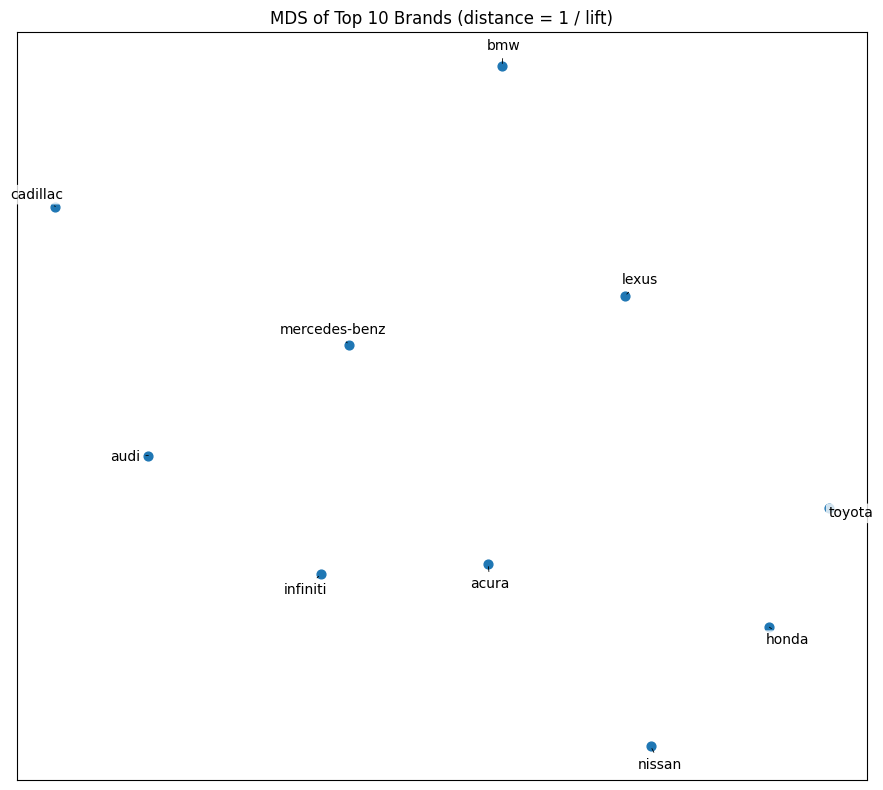

In [27]:
# ============================
# 9) MDS ONLY on the top-N brands
#     Distance = 1 / lift (bigger lift = closer). Stabilize with EPS.
# ============================
# Build distance matrix directly from lift among top brands
D = 1.0 / np.maximum(lift_top, EPS)
np.fill_diagonal(D, 0.0)

# (Optional) If you want to strongly downweight near-zero-support links, you can inflate distances
# where co-mentions are low:
# weak = C_top < MIN_COMENTION_SUPPORT
# D = D.copy()
# D[weak] = np.maximum(D[weak], np.median(D[~np.eye(len(top_brands), dtype=bool)]) * 5.0)
# np.fill_diagonal(D, 0.0)

mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=RANDOM_STATE,
    n_init=6,
    max_iter=1000,
)
coords = mds.fit_transform(D)  # shape (TOP_BRANDS_BY_COUNT, 2)

# ============================
# 10) Plot MDS for top-N brands
# ============================
plt.figure(figsize=(9, 8))
plt.scatter(coords[:, 0], coords[:, 1], s=40)

cx, cy = coords[:, 0].mean(), coords[:, 1].mean()
rx = max(np.ptp(coords[:, 0]), 1e-9)
ry = max(np.ptp(coords[:, 1]), 1e-9)

for i, name in enumerate(top_brands):
    dx, dy = coords[i, 0] - cx, coords[i, 1] - cy
    norm = np.hypot(dx, dy) + 1e-9
    ox = (dx / norm) * 0.03 * rx
    oy = (dy / norm) * 0.03 * ry
    plt.annotate(
        name,
        (coords[i, 0], coords[i, 1]),
        xytext=(coords[i, 0] + ox, coords[i, 1] + oy),
        textcoords="data",
        arrowprops=dict(arrowstyle="-", lw=0.6),
        fontsize=10, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    )

plt.title(f"MDS of Top {TOP_BRANDS_BY_COUNT} Brands (distance = 1 / lift)")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

## Part 3: Market Insights

### Task E: Insights from Lift and MDS Analyses

1. **Brand Co-Mention Clusters**  
   - The lift analysis reveals strong associations among *Japanese brands* (Honda–Toyota, Honda–Nissan, Acura–Honda) and among *luxury/premium brands* (Lexus–Infiniti, Lexus–Mercedes-Benz, Audi–Mercedes-Benz).  
   - For example, Honda–Toyota shows the highest lift (≈4.00), indicating these brands are co-mentioned about four times more often than expected by chance.

2. **Luxury vs. Mainstream Segmentation**  
   - The MDS map separates *premium brands* (Lexus, Mercedes-Benz, Audi, BMW, Cadillac) from *mainstream brands* (Honda, Toyota, Nissan).  
   - Acura and Infiniti serve as bridges between the two segments, reflecting their positioning as entry-level luxury.

3. **Competitive Closeness**  
   - Brands located near each other in the MDS map (e.g., Honda–Toyota, Lexus–Infiniti) likely compete for similar customer segments.  
   - Distant pairs (e.g., Cadillac–Toyota) show weaker associations, indicating less overlap in market positioning.

4. **Marketing and Strategic Insights**  
   - High-lift brand pairs highlight areas of direct competition, where differentiation strategies or competitive pricing may be crucial.  
   - Conversely, low-lift or distant pairs may indicate opportunities for cross-promotion or untapped market synergy.

5. **Industry-Wide Trend**  
   - The analysis reveals a market polarized between mainstream economy vehicles and luxury/premium brands, with mid-tier Japanese luxury (Acura, Infiniti, Lexus) forming a transitional cluster.


### Task F: Attributes

Gave 10 instead of 5 to ensure we picked the correct attributes

In [44]:
vec_all = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    stop_words="english"   # <-- built-in stopword list
)
X_all = vec_all.fit_transform(comments.values)

token_counts = np.asarray(X_all.sum(axis=0)).flatten()
all_tokens = pd.DataFrame({
    "token": vec_all.get_feature_names_out(),
    "count": token_counts
}).sort_values("count", ascending=False)

display(all_tokens.head(50))

,token,count
9054,car,6977
7838,bmw,3730
9247,cars,3695
22701,like,3544
21762,just,2970
13586,dont,2717
37496,tl,2513
37033,think,2257
17362,g35,1965
1869,3,1841


In [56]:
attributes = ['new', 'performance', 'luxury', 'price', 'interior']

In [57]:
# ----------------------------
# 1. Build alias vocab for attributes (just the attribute words)
# ----------------------------
attribute_vocab = {a: i for i, a in enumerate(attributes)}

vec_attr = CountVectorizer(
    vocabulary=attribute_vocab,
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
)
X_attr_counts = vec_attr.transform(comments.values)

# Binarize: 1 if attribute mentioned in comment, else 0
X_attr = (X_attr_counts > 0).astype(np.int8).tocsr()

# ----------------------------
# 2. Brand × Attribute co-mentions
# ----------------------------
Xb = X.astype(np.int32)      # brands (N_docs × N_brands)
Xa = X_attr.astype(np.int32) # attributes (N_docs × N_attributes)

# Co-mention counts: (brands × attributes)
C_ba = Xb.T @ Xa    # shape: n_brands × n_attributes

# Marginals
counts_b = np.asarray(Xb.sum(axis=0)).ravel()   # brand counts
counts_a = np.asarray(Xa.sum(axis=0)).ravel()   # attribute counts

# ----------------------------
# 3. Lift computation
# ----------------------------
ABplus = (C_ba.toarray() + K_SMOOTH).astype(float)
Aplus  = (counts_b[:, None] + K_SMOOTH).astype(float)
Bplus  = (counts_a[None, :] + K_SMOOTH).astype(float)

lift_ba = (N * ABplus) / (Aplus * Bplus + EPS)

# ----------------------------
# 4. Turn into a table for top brands
# ----------------------------
brands_top = counts_df.head(TOP_BRANDS_BY_COUNT)["brand"].tolist()
brand_idx_top = [brand_to_idx[b] for b in brands_top]

lift_records = []
for i, b in zip(brand_idx_top, brands_top):
    for j, attr in enumerate(attributes):
        lift_records.append((b, attr, int(C_ba[i, j]), float(lift_ba[i, j])))

lift_df = (
    pd.DataFrame(lift_records, columns=["brand","attribute","co_mentions","lift"])
      .sort_values(["lift","co_mentions"], ascending=[False,False])
      .reset_index(drop=True)
)

display(lift_df.head(10))  # top brand–attribute links

,brand,attribute,co_mentions,lift
0,toyota,luxury,150,2.407860
1,audi,interior,193,2.295179
2,mercedes-benz,luxury,179,2.116549
3,cadillac,interior,157,2.074961
4,acura,luxury,181,2.058034
5,lexus,luxury,317,2.038063
6,honda,luxury,149,1.992733
7,mercedes-benz,price,148,1.989494
8,infiniti,price,108,1.961229
9,infiniti,interior,90,1.955917


In [59]:
# For each attribute, keep only the brand with the highest lift
idx = lift_df.groupby("attribute")["lift"].idxmax()
lift_top_per_attribute = lift_df.loc[idx].reset_index(drop=True)

# Optional: sort by lift descending for display
lift_top_per_attribute = lift_top_per_attribute.sort_values("lift", ascending=False)

lift_top_per_attribute.reset_index(drop=True, inplace=True)

display(lift_top_per_attribute)

,brand,attribute,co_mentions,lift
0,toyota,luxury,150,2.407860
1,audi,interior,193,2.295179
2,mercedes-benz,price,148,1.989494
3,infiniti,new,157,1.896695
4,toyota,performance,134,1.762121


### Task G: Advice to Client

Social conversations about entry-level luxury cars concentrate on a small set of themes: luxury, interior quality, performance/handling, powertrain (engine, RWD), and price. These attributes drive how consumers frame comparisons, showing that buyers are balancing status and comfort with driving engagement and value.


**Key insights:**

- Luxury & interior quality dominate discussions, confirming that premium feel is the primary expectation in this segment.

- Performance cues (handling, RWD, engine) also emerge strongly, suggesting entry-luxury buyers want cars that feel more engaging than mainstream options.

- Price sensitivity is visible, indicating that consumers in this tier remain value-oriented, even when seeking premium features.

- Unexpectedly, Toyota is over-associated with “luxury” and “handling,” showing that mainstream brands can encroach on luxury perceptions. Lexus is also tied not just to luxury, but to “manual” transmissions, hinting at a niche of enthusiast interest within a brand typically known for comfort.

**Overall advice:**

Entry-luxury brands should position themselves around a blend of premium comfort and engaging performance, while also addressing price transparency. The blurred lines between mainstream and luxury marques signal that consumer expectations are shifting — buyers want attainable luxury without sacrificing driving enjoyment. Monitoring how attributes cluster in conversations over time will help identify where perception gaps open up and where competitors are over- or under-delivering.

### Task H: Aspirational Brand

In [60]:
# Define aspirational attributes
aspirational_attributes = ['luxury', 'performance', 'handling', 'power',
                           'reliable', 'comfort', 'safety', 'affordable', 'efficient']

# ----------------------------
# 1. Build alias vocab for attributes (just the attribute words)
# ----------------------------
aspirational_attributes_vocab = {a: i for i, a in enumerate(aspirational_attributes)}

vec_attr = CountVectorizer(
    vocabulary=aspirational_attributes_vocab,
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
)
X_attr_counts = vec_attr.transform(comments.values)

# Binarize: 1 if attribute mentioned in comment, else 0
X_attr = (X_attr_counts > 0).astype(np.int8).tocsr()

# ----------------------------
# 2. Brand × Attribute co-mentions
# ----------------------------
Xb = X.astype(np.int32)      # brands (N_docs × N_brands)
Xa = X_attr.astype(np.int32) # attributes (N_docs × N_attributes)

# Co-mention counts: (brands × attributes)
C_ba = Xb.T @ Xa    # shape: n_brands × n_attributes

# Marginals
counts_b = np.asarray(Xb.sum(axis=0)).ravel()   # brand counts
counts_a = np.asarray(Xa.sum(axis=0)).ravel()   # attribute counts

# ----------------------------
# 3. Lift computation
# ----------------------------
ABplus = (C_ba.toarray() + K_SMOOTH).astype(float)
Aplus  = (counts_b[:, None] + K_SMOOTH).astype(float)
Bplus  = (counts_a[None, :] + K_SMOOTH).astype(float)

lift_ba = (N * ABplus) / (Aplus * Bplus + EPS)

# ----------------------------
# 4. Turn into a table for top brands
# ----------------------------
brands_top = counts_df.head(TOP_BRANDS_BY_COUNT)["brand"].tolist()
brand_idx_top = [brand_to_idx[b] for b in brands_top]

lift_records = []
for i, b in zip(brand_idx_top, brands_top):
    for j, attr in enumerate(aspirational_attributes):
        lift_records.append((b, attr, int(C_ba[i, j]), float(lift_ba[i, j])))

aspirational_lift_df = (
    pd.DataFrame(lift_records, columns=["brand","attribute","co_mentions","lift"])
      .sort_values(["lift","co_mentions"], ascending=[False,False])
      .reset_index(drop=True)
)

display(aspirational_lift_df.head(10))  # top brand–attribute links

,brand,attribute,co_mentions,lift
0,toyota,comfort,148,15.898251
1,nissan,affordable,7,5.973716
2,nissan,efficient,10,4.718600
3,infiniti,affordable,6,4.095723
4,acura,affordable,7,3.340432
5,audi,efficient,16,3.145236
6,toyota,safety,31,3.121129
7,mercedes-benz,affordable,6,3.039382
8,mercedes-benz,reliable,41,2.913490
9,audi,affordable,8,2.898551


Most Aspirational Brand: toyota
Average Lift Score: 3.571896318032007


/tmp/ipython-input-287331087.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_lift_df.head(10), x="lift", y="brand", palette="viridis")


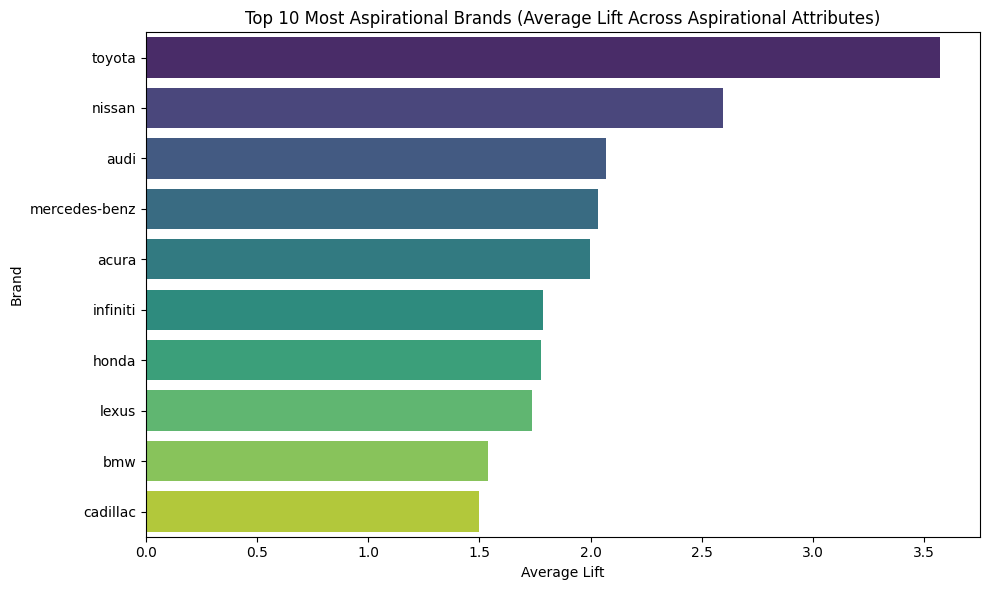

In [61]:
# Compute average lift across aspirational attributes
avg_lift_df = (
    aspirational_lift_df.groupby("brand")["lift"]
    .mean()
    .reset_index()
    .sort_values("lift", ascending=False)
)

# Identify the most aspirational brand
most_aspirational_brand = avg_lift_df.iloc[0]
print("Most Aspirational Brand:", most_aspirational_brand["brand"])
print("Average Lift Score:", most_aspirational_brand["lift"])

# Plot top 10 aspirational brands
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_lift_df.head(10), x="lift", y="brand", palette="viridis")
plt.title("Top 10 Most Aspirational Brands (Average Lift Across Aspirational Attributes)")
plt.xlabel("Average Lift")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

#### Business Implications for Toyota (the most aspirational brand)

- Toyota’s strong association with aspirational attributes suggests it is excelling in areas valued by mainstream buyers—not just luxury, but also reliability, safety, and efficiency.

- This opens opportunities to position select models (e.g., Camry, RAV4 Hybrid, Crown) as practical yet aspirational choices, appealing to buyers who want power, comfort, and modern features without paying luxury premiums.

- Toyota can strengthen its messaging around reliability, safety, and comfort, while showcasing efficient yet powerful powertrains (e.g., hybrids, plug-ins) to broaden its aspirational appeal.

- This positioning can serve as a bridge toward Lexus or premium trims, nurturing aspirational buyers who value practicality and affordability alongside refinement.

- Competitors in the affordable-premium and mainstream segments (e.g., Honda, Hyundai, Kia) should monitor Toyota’s ability to capture value-conscious aspirational buyers, as it may shift perceptions in these categories.

- Toyota’s aspirational lift may reduce the perceived gap between mainstream and luxury, particularly for buyers prioritizing dependable, efficient, and comfortable vehicles.